---
# Decision Tree (CART) From Scratch  
**Dataset:** Car Evaluation (categorical predictors)   
---

## 1. What we are building

A decision tree classifier is a supervised learning model that predicts a *categorical* outcome using a hierarchy of if–then split rules.

Unlike linear or probabilistic classifiers, decision trees recursively partition the feature space into disjoint regions. Each internal node corresponds to a feature-based decision rule, while each leaf node represents a class distribution over the samples that reach it.

In this notebook, we apply a **from-scratch CART decision tree classifier**, implemented in `src/rice_ml`, to the **Car Evaluation** dataset. The tree is trained using the **Gini impurity** criterion and greedy recursive splitting.

All six predictors in the dataset are categorical, making this a natural setting for decision trees, which handle discrete decision boundaries well without requiring feature scaling.

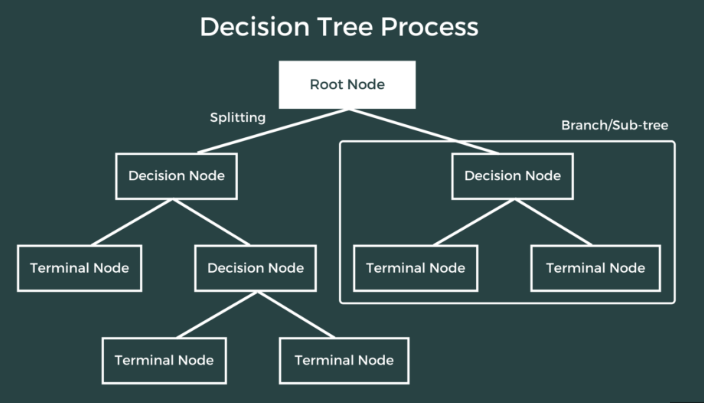

## 2. Setup and Imports
This section imports all required libraries and ensures the custom decision tree implementation from the `rice_ml` package can be imported correctly.

All model training and prediction logic comes from the source code in `src/`. No external machine-learning libraries are used in the core algorithm.

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append(os.path.abspath("../../../src"))

from rice_ml.supervised_learning.decision_trees import DecisionTreeClassifier

DATA_PATH = "car_evaluation.csv"


## 3. Data Loading and Column Standardization

This cell loads the dataset from CSV or Excel. If the file does not contain a header row (a common format for the Car Evaluation dataset), standard column names are assigned.

The output confirms the dataset shape and displays the first few rows for verification.

In [8]:
def load_table(path: str) -> pd.DataFrame:
    ext = os.path.splitext(path)[1].lower()

    if ext in [".xlsx", ".xls"]:
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path)
        if all(str(c).isdigit() for c in df.columns):
            df = pd.read_csv(path, header=None)

    if df.shape[1] == 7:
        df.columns = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
    elif "class" not in df.columns:
        cols = list(df.columns)
        cols[-1] = "class"
        df.columns = cols

    return df


df_raw = load_table(DATA_PATH)

print("Loaded shape:", df_raw.shape)
print("Columns:", list(df_raw.columns))
df_raw.head()


Loaded shape: (1727, 7)
Columns: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


## 4. Initial Data Quality Checks

Before modeling, we check for common data issues:
- Missing values
- Empty strings after trimming whitespace
- Duplicate rows

These checks help verify that the dataset is suitable for modeling and that no hidden cleaning issues remain.


In [9]:
df = df_raw.copy()

print("Missing values per column:\n", df.isna().sum())

trimmed = df.astype(str).apply(lambda s: s.str.strip())
empty_counts = (trimmed == "").sum()
print("\nEmpty-string counts (after strip):\n", empty_counts)

dup_count = df.duplicated().sum()
print("\nDuplicate rows:", int(dup_count))


Missing values per column:
 buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Empty-string counts (after strip):
 buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

Duplicate rows: 0


## 5. Target Class Distribution

Before fitting the model, we examine the distribution of the target variable (class).

Understanding class imbalance is important for interpreting classification performance. In the Car Evaluation dataset, the majority of observations belong to the unacc class, while good and vgood are relatively rare. This imbalance should be kept in mind when evaluating accuracy and confusion matrices.


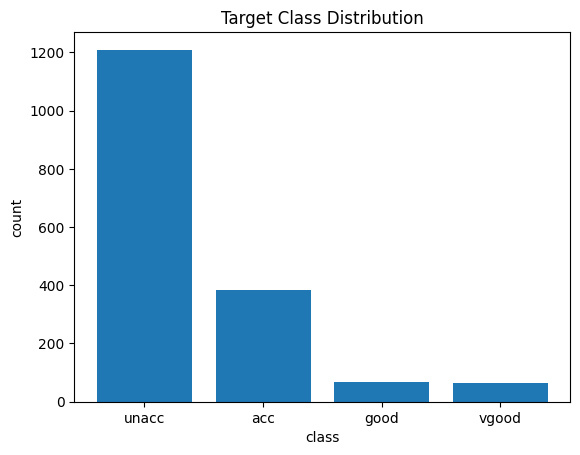

class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64

In [28]:
target_counts = df["class"].value_counts()

plt.figure()
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Target Class Distribution")
plt.xlabel("class")
plt.ylabel("count")
plt.show()

target_counts


## 6. Ordinal Encoding of Categorical Features

All input features in the Car Evaluation dataset are categorical. However, the from-scratch DecisionTreeClassifier implemented in `src/rice_ml` performs numerical threshold comparisons of the form

$$x_j \leq t$$

Therefore, categorical values must be converted into numerical representations before training.

In this notebook, we apply simple ordinal encodings to each feature. The encoding preserves the natural ordering implied by the category labels (e.g., low < med < high < vhigh) and allows the decision tree to evaluate meaningful split thresholds.

This preprocessing step is handled entirely in the notebook. The tree-building algorithm itself remains unchanged and purely implemented in the source code.

In [20]:
CAT_MAPS = {
    "buying":  {"low": 0, "med": 1, "high": 2, "vhigh": 3},
    "maint":   {"low": 0, "med": 1, "high": 2, "vhigh": 3},
    "doors":   {"2": 0, "3": 1, "4": 2, "5more": 3},
    "persons": {"2": 0, "4": 1, "more": 2},
    "lug_boot":{"small": 0, "med": 1, "big": 2},
    "safety":  {"low": 0, "med": 1, "high": 2},
}

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

for col, mapping in CAT_MAPS.items():
    X_train_enc[col] = X_train_enc[col].map(mapping)
    X_test_enc[col] = X_test_enc[col].map(mapping)

X_train_enc.head()


,buying,maint,doors,persons,lug_boot,safety
0,3,3,0,0,0,1
1,3,3,0,0,0,2
2,3,3,0,0,1,0
3,3,3,0,0,1,1
4,3,3,0,0,1,2


## 7. Training the From-Scratch Decision Tree Classifier

We now train a CART-style decision tree classifier implemented entirely from scratch in the `rice_ml` package.

The model uses:

- Gini impurity as the split criterion
- Greedy recursive splitting
- User-specified regularization parameters such as maximum depth and minimum leaf size

In [22]:
from rice_ml.supervised_learning.decision_trees import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=0
)

tree.fit(
    X_train_enc.to_numpy(),
    y_train.astype(int)
)

print("Tree trained successfully.")
print("Number of features:", tree.n_features_)
print("Number of classes:", tree.n_classes_)


Tree trained successfully.
Number of features: 6
Number of classes: 4


## 8. Model Evaluation on the Test Set

After training, we evaluate the decision tree on the held-out test set.

We report the overall classification accuracy, defined as the proportion of correctly predicted samples. While accuracy provides a useful summary measure, it does not capture class-specific performance, especially in the presence of class imbalance.

In [23]:
y_pred = tree.predict(X_test_enc.to_numpy())

accuracy = np.mean(y_pred == y_test)
print("Test accuracy:", accuracy)


Test accuracy: 0.8294797687861272


## 9. Confusion Matrix

To gain a more detailed view of model performance, we compute the confusion matrix.

Each row corresponds to the true class label, and each column corresponds to the predicted class label. This representation highlights which classes are well separated by the decision tree and where misclassifications occur.

In [24]:
confusion = pd.crosstab(
    pd.Series(y_test, name="True"),
    pd.Series(y_pred, name="Predicted")
)

confusion


Predicted,0,1,2,3
True,,,,
0,234,2,4,2
1,7,26,20,24
2,0,0,14,0
3,0,0,0,13


## 10. Class Probability Predictions

In addition to hard class predictions, the decision tree can output class probability estimates.

At each leaf node, the predicted probabilities correspond to the empirical class frequencies of the training samples that reached that leaf. These probabilities provide insight into the model's uncertainty and can be useful for downstream decision-making.

In [25]:
proba = tree.predict_proba(X_test_enc.to_numpy())

proba_df = pd.DataFrame(
    proba,
    columns=[f"class_{i}" for i in range(proba.shape[1])]
)

proba_df.head()


,class_0,class_1,class_2,class_3
0,0.000000,0.409091,0.0,0.590909
1,1.000000,0.000000,0.0,0.000000
2,0.194444,0.805556,0.0,0.000000
3,1.000000,0.000000,0.0,0.000000
4,1.000000,0.000000,0.0,0.000000


## 11. Feature-Level Analysis of Predictions

To better understand how the decision tree partitions the data, we analyze predicted class distributions conditioned on individual features.

As an example, we examine how predicted classes vary across different levels of the safety feature. This type of analysis helps interpret which feature values are most strongly associated with certain outcomes.

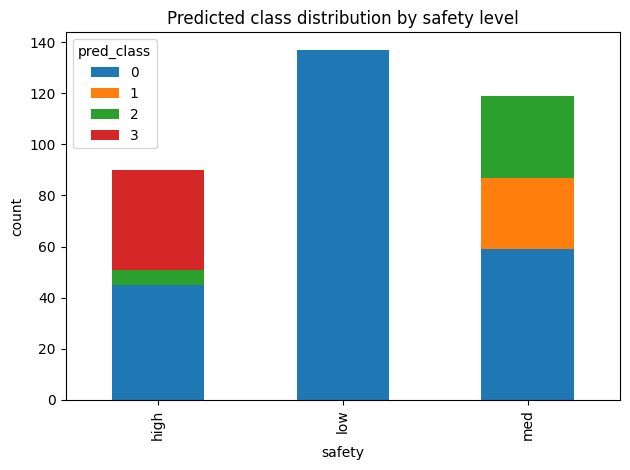

In [26]:
plot_df = X_test.copy()
plot_df["true_class"] = y_test
plot_df["pred_class"] = y_pred

ct = pd.crosstab(plot_df["safety"], plot_df["pred_class"])

ct.plot(kind="bar", stacked=True)
plt.title("Predicted class distribution by safety level")
plt.xlabel("safety")
plt.ylabel("count")
plt.tight_layout()
plt.show()


## 12. Visualization with scikit-learn

For visualization purposes only, we fit a decision tree classifier from scikit-learn using one-hot encoded features and plot the resulting tree structure.

This step is not used for training or evaluation and does not replace the from-scratch implementation. Instead, it serves as a visual reference to illustrate the hierarchical decision rules learned by a CART-style classifier in a familiar format.

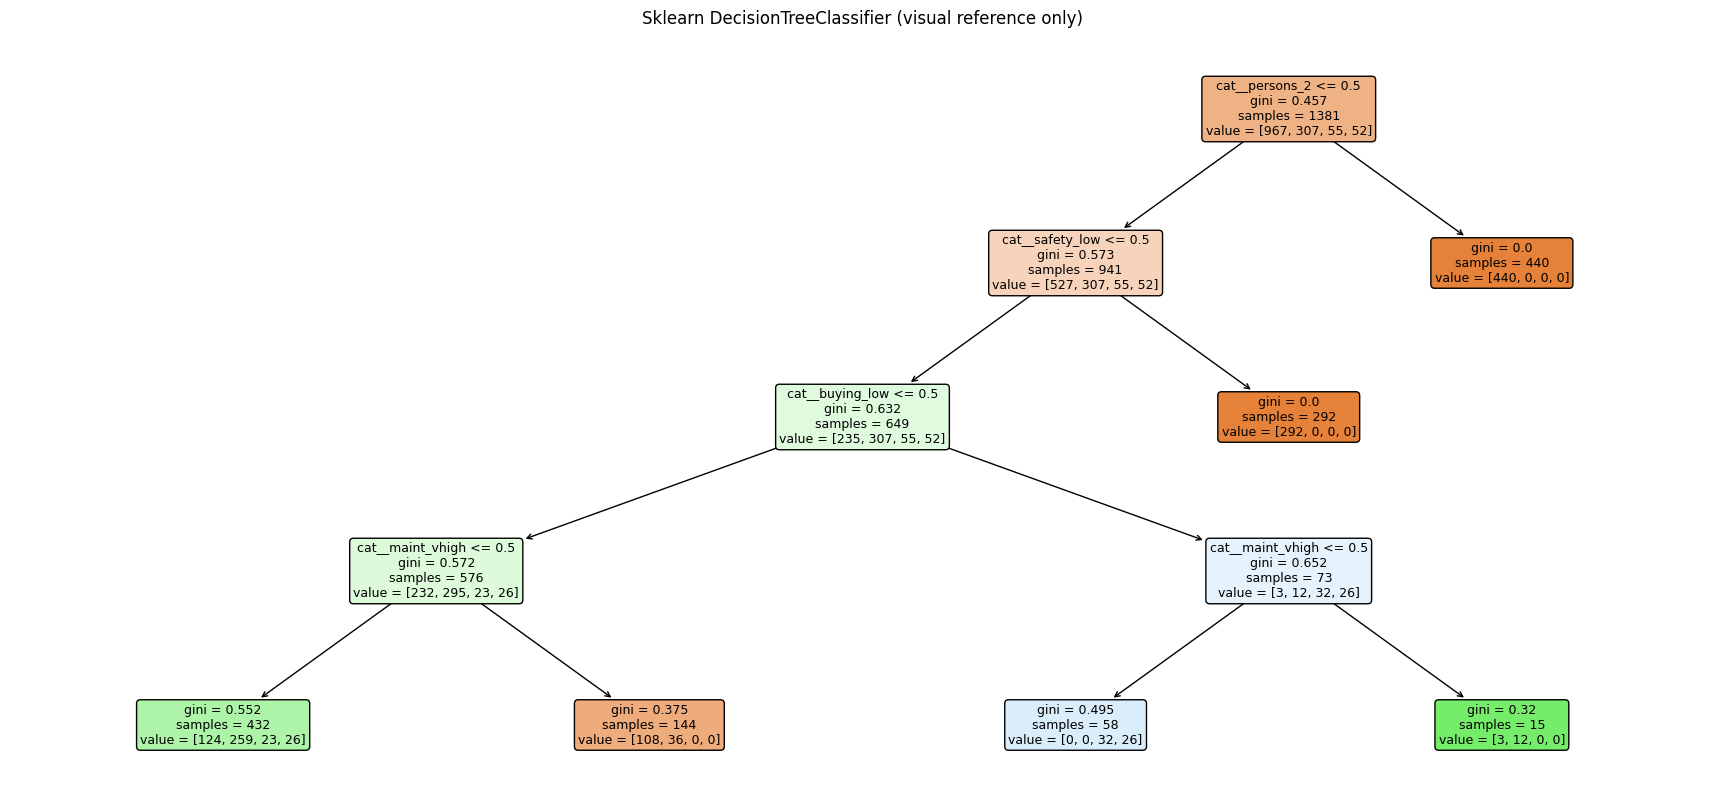

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier as SkDT, plot_tree

pre = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), X_COLS)],
    remainder="drop"
)

sk_tree = SkDT(
    max_depth=4,
    min_samples_leaf=10,
    random_state=0
)

pipe = Pipeline(steps=[
    ("pre", pre),
    ("model", sk_tree)
])

pipe.fit(X_train, y_train)

feature_names = pipe.named_steps["pre"].get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    pipe.named_steps["model"],
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Sklearn DecisionTreeClassifier")
plt.show()


## 13. Summary

This notebook demonstrated that decision trees can effectively handle purely categorical data through ordinal encoding, achieving 82.9% test accuracy on the Car Evaluation dataset. The confusion matrix revealed that the model performs exceptionally well on the dominant `unacc` class (234/242 correct) and the rare `vgood` class (13/13 correct), but struggles with the intermediate `acc` and `good` classes, where misclassifications are more frequent.

The strong performance on `vgood` despite its small sample size (only 65 training examples) suggests that this class has distinctive feature combinations that the tree can isolate effectively. In contrast, the `acc` class shows substantial confusion with neighboring classes, particularly being misclassified as `good` (20 cases) and `vgood` (24 cases), indicating overlapping decision boundaries in the feature space.

The feature-level analysis confirmed that `safety` is a dominant splitting variable, with low safety values strongly associated with `unacc` predictions. This aligns with domain intuition—cars with poor safety are rarely acceptable regardless of other attributes.

The from-scratch implementation successfully replicated the core CART algorithm behavior, as evidenced by the scikit-learn visualization showing similar hierarchical splitting patterns. The hyperparameters (`max_depth=6`, `min_samples_leaf=10`) provided effective regularization, preventing overfitting while maintaining interpretability. The class probability outputs further demonstrated that the model appropriately expresses uncertainty in ambiguous regions of the feature space, with some leaves showing near-uniform distributions across multiple classes.